# Match Outcome Prediction — Logistic Regression

**Hypothesis:** Disposals differential, contested possessions differential, and inside-50s differential can predict match outcomes.

**Method:** Aggregate player stats to team-game level, compute differentials (home minus away), fit logistic regression, evaluate with ROC AUC and confusion matrix.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
DB = '../data/database/afl_analytics.db'
conn = sqlite3.connect(DB)

In [2]:
# Aggregate player stats to team level per game (season + round)
team_game_stats = pd.read_sql("""
    SELECT
        f.team_key,
        f.season_key,
        f.round,
        SUM(f.disposals)             AS total_disposals,
        SUM(f.contested_possessions) AS total_contested,
        SUM(f.inside_50s)            AS total_i50,
        SUM(f.clearances)            AS total_clearances,
        SUM(f.tackles)               AS total_tackles,
        SUM(f.marks)                 AS total_marks
    FROM fact_player_match_stats f
    WHERE f.disposals IS NOT NULL
    GROUP BY f.team_key, f.season_key, f.round
""", conn)

# Match results
matches = pd.read_sql("""
    SELECT mr.match_key, mr.season_key, mr.round,
           mr.home_team_key, mr.away_team_key,
           mr.home_total_score, mr.away_total_score,
           mr.winning_team_key, mr.is_final
    FROM fact_match_results mr
    WHERE mr.home_total_score IS NOT NULL AND mr.is_final = 0
""", conn)

print(f'Team-game rows: {len(team_game_stats)}')
print(f'Matches: {len(matches)}')

Team-game rows: 5762
Matches: 2960


In [3]:
# Join home team stats and away team stats onto each match
stats_cols = ['total_disposals','total_contested','total_i50','total_clearances','total_tackles','total_marks']

home_stats = team_game_stats.rename(columns={c: f'home_{c}' for c in stats_cols})
away_stats = team_game_stats.rename(columns={c: f'away_{c}' for c in stats_cols})

df = matches.merge(
    home_stats.rename(columns={'team_key':'home_team_key'}),
    on=['home_team_key','season_key','round'], how='inner'
).merge(
    away_stats.rename(columns={'team_key':'away_team_key'}),
    on=['away_team_key','season_key','round'], how='inner'
)

# Target: 1 = home team wins
df['home_win'] = (df['winning_team_key'] == df['home_team_key']).astype(int)

# Differentials (home minus away)
for col in stats_cols:
    df[f'diff_{col}'] = df[f'home_{col}'] - df[f'away_{col}']

print(f'Matched rows: {len(df)}')
print(f'Home win rate: {df.home_win.mean():.1%}')

Matched rows: 2744
Home win rate: 55.9%


In [4]:
# Feature set
feature_cols = [f'diff_{c}' for c in stats_cols]
X = df[feature_cols].fillna(0)
y = df['home_win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

# Cross-validated AUC
cv_scores = cross_val_score(model, scaler.transform(X), y, cv=5, scoring='roc_auc')
print(f'5-fold CV ROC AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-fold CV ROC AUC: 0.8428 +/- 0.0740


In [5]:
# Evaluation
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:,1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Away Win','Home Win']))
print(f'ROC AUC (test): {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.71      0.67      0.69       242
    Home Win       0.75      0.79      0.77       307

    accuracy                           0.73       549
   macro avg       0.73      0.73      0.73       549
weighted avg       0.73      0.73      0.73       549

ROC AUC (test): 0.8234


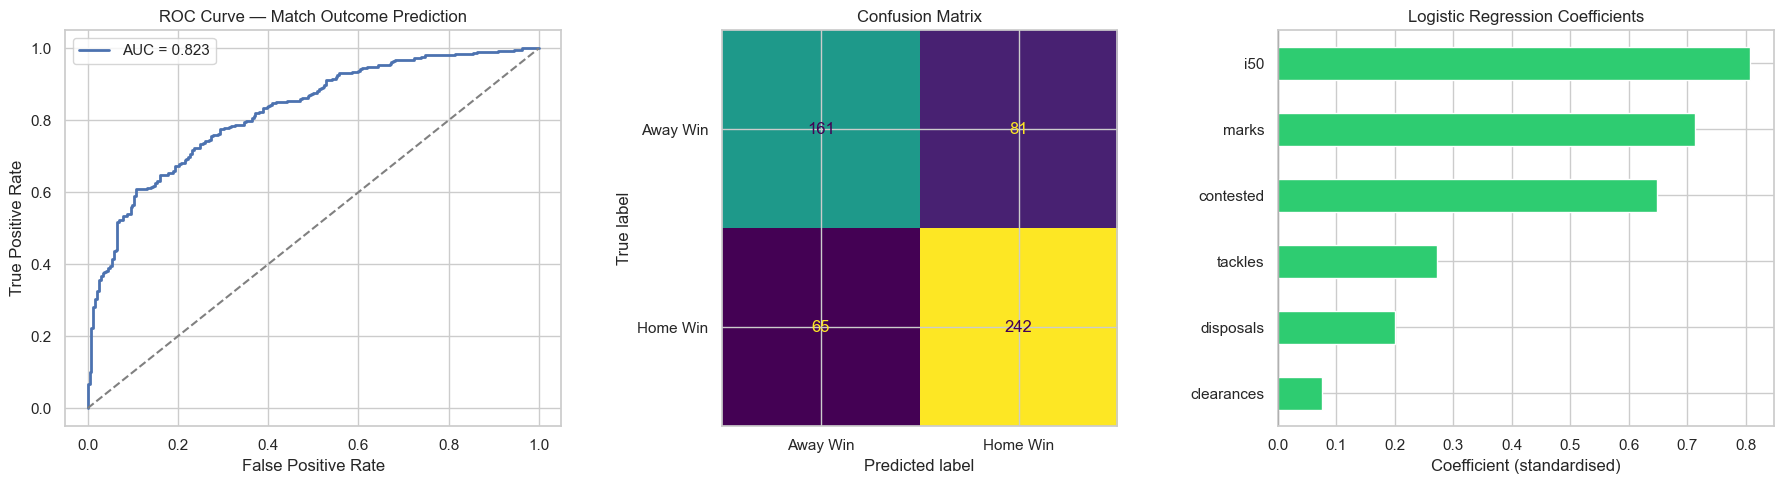

In [6]:
# Plots: ROC curve + Confusion matrix + Feature coefficients
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'--', color='grey')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Match Outcome Prediction')
axes[0].legend()

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Away Win','Home Win']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix')

# Feature importance (coefficients)
feat_names = [c.replace('diff_total_','') for c in feature_cols]
coefs = pd.Series(model.coef_[0], index=feat_names).sort_values()
coefs.plot(kind='barh', ax=axes[2], color=['#e74c3c' if c < 0 else '#2ecc71' for c in coefs])
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Logistic Regression Coefficients')
axes[2].set_xlabel('Coefficient (standardised)')

plt.tight_layout()
plt.show()

conn.close()